In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. Manual Metric Functions
def manual_roc_curve(y_true, y_score):
    desc_idx = np.argsort(-y_score)
    y_score = y_score[desc_idx]
    y_true = y_true[desc_idx]
    distinct_idx = np.where(np.diff(y_score))[0]
    threshold_idx = np.concatenate([distinct_idx, [len(y_true) - 1]])
    tps = np.cumsum(y_true)[threshold_idx]
    fps = (threshold_idx + 1) - tps
    tps = np.concatenate([[0], tps])
    fps = np.concatenate([[0], fps])
    fpr = fps / fps[-1] if fps[-1] > 0 else fps
    tpr = tps / tps[-1] if tps[-1] > 0 else tps
    return fpr, tpr

def manual_auc(x, y):
    order = np.argsort(x)
    x, y = x[order], y[order]
    return float(np.trapz(y, x))

# 2. Paths
heatmap_path = '/data/akheirandish3/PaDIS_results/DDAD/results/combinedsample9_heatmap.npy'
sample_name = "image_0011"
gt_mask_path = f"/data2/akheirandish3/id_new_warped_images/masks_ood_med_med/{sample_name}_mask.png"

TARGET_SIZE = (256, 256)

if os.path.exists(heatmap_path) and os.path.exists(gt_mask_path):
    # ==========================
    # 3. Load & Process Heatmap
    # ==========================
    heatmap = np.load(heatmap_path)
    print(f"Heatmap raw shape: {heatmap.shape}")
    
    # Remove channel dim if present (1, H, W) -> (H, W)
    if heatmap.ndim == 3:
        heatmap = heatmap.squeeze()
        
    # Resize to 256x256 using Bilinear interpolation
    # mode='F' preserves floating point precision of anomaly scores
    heatmap_pil = Image.fromarray(heatmap, mode='F') 
    heatmap_resized = heatmap_pil.resize(TARGET_SIZE, resample=Image.BILINEAR)
    heatmap_final = np.array(heatmap_resized)
    
    # ==========================
    # 4. Load & Process Mask
    # ==========================
    mask_pil = Image.open(gt_mask_path).convert("L")
    # Resize to 256x256 using Nearest Neighbor (preserves binary nature)
    mask_resized = mask_pil.resize(TARGET_SIZE, resample=Image.NEAREST)
    mask_final = np.array(mask_resized)
    
    # Binarize
    gt_mask_binary = (mask_final > 0).astype(np.uint8)
    
    print(f"Final Heatmap Shape: {heatmap_final.shape}")
    print(f"Final Mask Shape: {gt_mask_binary.shape}")
    
    # ==========================
    # 5. Calculate AUC
    # ==========================
    pixel_scores = heatmap_final.ravel()
    pixel_labels = gt_mask_binary.ravel()
    
    fpr, tpr = manual_roc_curve(pixel_labels, pixel_scores)
    roc_auc = manual_auc(fpr, tpr)
    
    print(f"\nPixel-Level AUC: {roc_auc:.4f}")
    
    # ==========================
    # 6. Plot
    # ==========================
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(heatmap_final, cmap='hot')
    plt.title(f'Heatmap ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_binary, cmap='gray')
    plt.title(f'GT Mask ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

else:
    print(f"Error: Files not found.")
    print(f"Heatmap exists: {os.path.exists(heatmap_path)}")
    print(f"Mask path exists: {os.path.exists(gt_mask_path)}")

Error: Files not found.
Heatmap exists: False
Mask path exists: True


Heatmap raw shape: (1, 224, 224)
Final Heatmap Shape: (256, 256)
Final Mask Shape: (256, 256)

Pixel-Level AUC: 0.9551


/tmp/ipykernel_393145/3706017842.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))


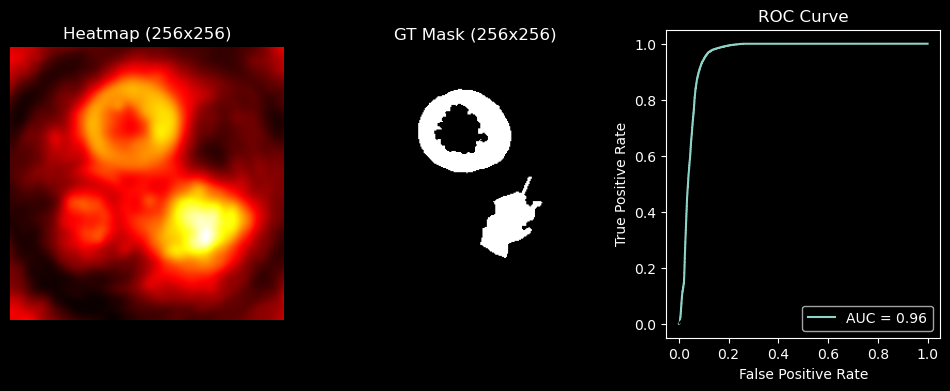

In [2]:
# gt_mask_path = f"/data/akheirandish3/mvtec_ad/cable/ground_truth/combined/{sample}_mask.png"
heatmap_path = '/data/akheirandish3/PaDIS_results/DDAD/results_cable/cablesample0_heatmap.npy'
sample_name = "009"
gt_mask_path = f"/data/akheirandish3/mvtec_ad/cable/ground_truth/combined/{sample_name}_mask.png"

TARGET_SIZE = (256, 256)

if os.path.exists(heatmap_path) and os.path.exists(gt_mask_path):
    # ==========================
    # 3. Load & Process Heatmap
    # ==========================
    heatmap = np.load(heatmap_path)
    print(f"Heatmap raw shape: {heatmap.shape}")
    
    # Remove channel dim if present (1, H, W) -> (H, W)
    if heatmap.ndim == 3:
        heatmap = heatmap.squeeze()
        
    # Resize to 256x256 using Bilinear interpolation
    # mode='F' preserves floating point precision of anomaly scores
    heatmap_pil = Image.fromarray(heatmap, mode='F') 
    heatmap_resized = heatmap_pil.resize(TARGET_SIZE, resample=Image.BILINEAR)
    heatmap_final = np.array(heatmap_resized)
    
    # ==========================
    # 4. Load & Process Mask
    # ==========================
    mask_pil = Image.open(gt_mask_path).convert("L")
    # Resize to 256x256 using Nearest Neighbor (preserves binary nature)
    mask_resized = mask_pil.resize(TARGET_SIZE, resample=Image.NEAREST)
    mask_final = np.array(mask_resized)
    
    # Binarize
    gt_mask_binary = (mask_final > 0).astype(np.uint8)
    
    print(f"Final Heatmap Shape: {heatmap_final.shape}")
    print(f"Final Mask Shape: {gt_mask_binary.shape}")
    
    # ==========================
    # 5. Calculate AUC
    # ==========================
    pixel_scores = heatmap_final.ravel()
    pixel_labels = gt_mask_binary.ravel()
    
    fpr, tpr = manual_roc_curve(pixel_labels, pixel_scores)
    roc_auc = manual_auc(fpr, tpr)
    
    print(f"\nPixel-Level AUC: {roc_auc:.4f}")
    
    # ==========================
    # 6. Plot
    # ==========================
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(heatmap_final, cmap='hot')
    plt.title(f'Heatmap ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_binary, cmap='gray')
    plt.title(f'GT Mask ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

else:
    print(f"Error: Files not found.")
    print(f"Heatmap exists: {os.path.exists(heatmap_path)}")
    print(f"Mask path exists: {os.path.exists(gt_mask_path)}")

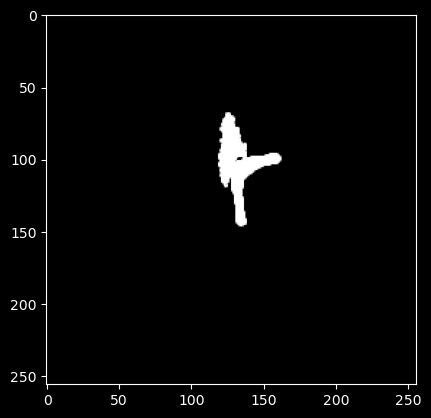

In [3]:
temp = plt.imread("/data/akheirandish3/mvtec_ad/faces/ground_truth/random/65_mask.png")
plt.imshow(temp)

Heatmap raw shape: (1, 224, 224)
Final Heatmap Shape: (256, 256)
Final Mask Shape: (256, 256)

Pixel-Level AUC: 0.0963


/tmp/ipykernel_393145/3706017842.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, x))


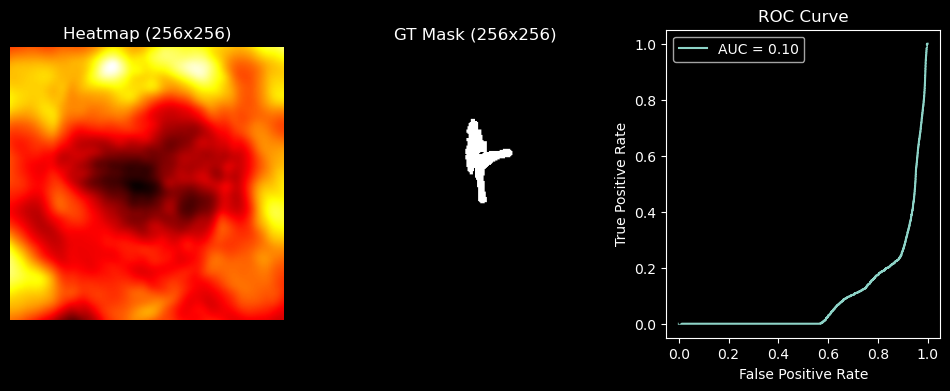

In [5]:
# gt_mask_path = f"/data/akheirandish3/mvtec_ad/cable/ground_truth/combined/{sample}_mask.png"
heatmap_path = '/data/akheirandish3/PaDIS_results/DDAD/results/facessample1_heatmap.npy'
sample_name = "65"
gt_mask_path = f"/data/akheirandish3/mvtec_ad/faces/ground_truth/random/{sample_name}_mask.png"

TARGET_SIZE = (256, 256)

if os.path.exists(heatmap_path) and os.path.exists(gt_mask_path):
    # ==========================
    # 3. Load & Process Heatmap
    # ==========================
    heatmap = np.load(heatmap_path)
    print(f"Heatmap raw shape: {heatmap.shape}")
    
    # Remove channel dim if present (1, H, W) -> (H, W)
    if heatmap.ndim == 3:
        heatmap = heatmap.squeeze()
        
    # Resize to 256x256 using Bilinear interpolation
    # mode='F' preserves floating point precision of anomaly scores
    heatmap_pil = Image.fromarray(heatmap, mode='F') 
    heatmap_resized = heatmap_pil.resize(TARGET_SIZE, resample=Image.BILINEAR)
    heatmap_final = np.array(heatmap_resized)
    
    # ==========================
    # 4. Load & Process Mask
    # ==========================
    mask_pil = Image.open(gt_mask_path).convert("L")
    # Resize to 256x256 using Nearest Neighbor (preserves binary nature)
    mask_resized = mask_pil.resize(TARGET_SIZE, resample=Image.NEAREST)
    mask_final = np.array(mask_resized)
    
    # Binarize
    gt_mask_binary = (mask_final > 0).astype(np.uint8)
    
    print(f"Final Heatmap Shape: {heatmap_final.shape}")
    print(f"Final Mask Shape: {gt_mask_binary.shape}")
    
    # ==========================
    # 5. Calculate AUC
    # ==========================
    pixel_scores = heatmap_final.ravel()
    pixel_labels = gt_mask_binary.ravel()
    
    fpr, tpr = manual_roc_curve(pixel_labels, pixel_scores)
    roc_auc = manual_auc(fpr, tpr)
    
    print(f"\nPixel-Level AUC: {roc_auc:.4f}")
    
    # ==========================
    # 6. Plot
    # ==========================
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(heatmap_final, cmap='hot')
    plt.title(f'Heatmap ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_binary, cmap='gray')
    plt.title(f'GT Mask ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

else:
    print(f"Error: Files not found.")
    print(f"Heatmap exists: {os.path.exists(heatmap_path)}")
    print(f"Mask path exists: {os.path.exists(gt_mask_path)}")

In [ ]:
import os
from glob import glob
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Change this to the directory you want to inspect
directory = '/data/akheirandish3/mvtec_ad/faces/ground_truth/random'

# Collect supported files
patterns = ['*.npy', '*.png', '*.jpg', '*.jpeg', '*.bmp']
files = []
for pattern in patterns:
    files.extend(glob(os.path.join(directory, pattern)))
files = sorted(files)

print(f'Found {len(files)} files in {directory}')

if not files:
    print('No supported files found.')
else:
    ncols = 3
    nrows = math.ceil(len(files) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(files):]:
        ax.axis('off')

    for ax, file_path in zip(axes, files):
        ext = os.path.splitext(file_path)[1].lower()
        title = os.path.basename(file_path)

        if ext == '.npy':
            data = np.load(file_path)
            if data.ndim == 3 and data.shape[0] == 1:
                data = data.squeeze(0)
            if data.ndim == 3 and data.shape[-1] in (3, 4):
                ax.imshow(data)
            else:
                ax.imshow(np.squeeze(data), cmap='hot')
        else:
            data = Image.open(file_path)
            ax.imshow(data)

        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()